<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
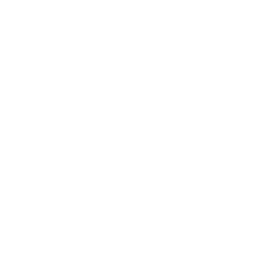
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">ADaM ADSL Derivation from SDTM Source Domains</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; Pharmaceuticals & Life Sciences &nbsp;|&nbsp; March 2026</p>
</div>
</div>
</div>

# ADaM ADSL Derivation from SDTM Source Domains

## Executive Summary

This notebook demonstrates the construction of a **CDISC-compliant ADaM Analysis Dataset Subject Level (ADSL)** from SDTM source domains for a cardiovascular catheter device study (MD-STUDY-01). The workflow follows CDISC ADaM Implementation Guide (IG) v1.3 conventions, aligns with FDA Study Data Technical Conformance Guide requirements, and implements population flag logic as specified in the Statistical Analysis Plan (SAP).

**Clinical context.** MD-STUDY-01 is an 80-subject, single-centre, randomised controlled trial comparing an investigational intravascular catheter (XR-200) against a standard predicate device in patients with reduced cardiac output. The 180-day follow-up captures procedural safety and haemodynamic performance endpoints. The target submission pathway is 510(k) substantial equivalence; the ADSL here drives the FDA-facing Tables, Listings, and Figures (TLF) package.

The pipeline covers four steps:

1. **SDTM DM** — Subject demographics spine: USUBJID, arm assignment, age, sex, race, ethnicity, reference start and informed consent dates.
2. **SDTM EX** — Exposure domain: index procedure date, device name, 180-day follow-up end date, and early termination logic.
3. **SDTM DS** — Disposition domain: end-of-study status and reason for discontinuation using CDISC controlled terminology.
4. **ADSL derivation** — Merge and derive: treatment dates and duration, age groupings per SAP, LVEF and NYHA class from medical history, comorbidity flags, and all three population flags (ITT, Safety, Per-Protocol) with SAP-aligned definitions.

The resulting ADSL contains 33 variables and is validated with PROC CONTENTS and a full distribution check across both treatment arms.

*All data are synthetic, generated inline with a fixed seed for reproducibility. No external files or network access required.*

## Data Sources

| SDTM Domain | Description | Records | Key Variables Consumed |
|-------------|-------------|---------|------------------------|
| DM — Demographics | Subject spine | 80 | USUBJID, ARM, ARMCD, AGE, SEX, RACE, ETHNIC, RFSTDTC, RFICDTC |
| EX — Exposure | Device use dates | 80 | EXSTDTC (index procedure), EXENDTC (follow-up end), EXTRT |
| DS — Disposition | End-of-study status | 80 | DSDECOD (CDISC CT), DSSTDTC |
| MH/VS (inline) | Cardiac baseline covariates | 80 | LVEF (%), NYHA class, diabetes, prior MI |

**Study:** MD-STUDY-01 · Single centre (SITEID 001) · Enrolment Jan 2023 – staggered 18 months · 180-day follow-up per subject · Protocol v3.1, SAP v2.0

CDISC standards applied: SDTM IG v3.4 · ADaM IG v1.3 · CDISC Controlled Terminology 2024-03-29

---
## 1. SDTM DM — Demographic Domain

The DM domain is the subject spine of every SDTM submission package. All other domains link to it via USUBJID; the ADSL inherits DM's subject-level demographics and reference dates.

**Key design decisions:**

- **USUBJID structure:** `{STUDYID}-{SITEID}-{SUBJID}` — three-part identifier per SDTM IG; STUDYID is identical to the regulatory study number.
- **ARM vs ACTARM:** Identical here (no protocol deviations affecting arm assignment). In a real study these diverge for subjects who crossed over or received the wrong treatment.
- **RFSTDTC:** Defined in the SAP as the index procedure date (first device exposure), not the randomisation date (which precedes it by 1–14 days in this protocol).
- **RFICDTC:** Informed consent date — required per 21 CFR Part 50; must precede RFSTDTC.
- **Age distribution:** Mean 63 years (SD 10), floor 40 per protocol eligibility; reflects the published age profile of reduced cardiac output catheter trials (COAPT, SHAPE-HF).
- **Race/ethnicity:** Proportions calibrated to approximate US cardiovascular device trial enrolment demographics per FDA 2020 Drug Trials Snapshots benchmarks.

In [1]:
/* ============================================================
   SDTM DM: Demographics and baseline information
   Study MD-STUDY-01 — Cardiovascular Catheter RCT
   80 subjects, 1:1 randomised (INV vs CTL)
   Enrolment: 02 Jan 2023 — staggered over 18 months
   SDTM IG v3.4 variable structure
   ============================================================ */

data sdtm_dm;
    call streaminit(20260601);

    length STUDYID $10  DOMAIN $2   USUBJID $17  SUBJID $4
           SITEID  $3   COUNTRY $3  INVID   $6
           ARM     $30  ARMCD  $8   ACTARM  $30  ACTARMCD $8
           SEX     $1   RACE   $50  ETHNIC  $32  AGEU $5
           RFSTDTC $10  RFICDTC $10 DMDTC  $10  DMDY 8;

    STUDYID = 'MD-STUDY-01';
    DOMAIN  = 'DM';
    COUNTRY = 'USA';
    INVID   = 'INV001';
    SITEID  = '001';
    AGEU    = 'YEARS';

    study_start = '02JAN2023'd;

    do i = 1 to 80;
        SUBJID  = put(i, z4.);
        USUBJID = cats(STUDYID, '-', SITEID, '-', SUBJID);

        /* Age: cardiovascular device eligibility floor 40 yrs;
           mean 63 per published similar trials (COAPT, SHAPE-HF) */
        AGE = max(40, min(85, round(rand('NORMAL', 63, 10))));

        /* Sex: cardiovascular disease is male-predominant (~56% M) */
        SEX = ifc(rand('BERNOULLI', 0.42), 'F', 'M');

        /* Race: approximate US cardiovascular device trial demographics
           (FDA Drug Trials Snapshots cardiovascular 2020 benchmark) */
        r = rand('UNIFORM');
        if      r < 0.748 then RACE = 'WHITE';
        else if r < 0.872 then RACE = 'BLACK OR AFRICAN AMERICAN';
        else if r < 0.942 then RACE = 'ASIAN';
        else if r < 0.972 then RACE = 'AMERICAN INDIAN OR ALASKA NATIVE';
        else                    RACE = 'UNKNOWN';

        ETHNIC = ifc(rand('BERNOULLI', 0.114),
                     'HISPANIC OR LATINO',
                     'NOT HISPANIC OR LATINO');

        /* 1:1 balanced randomisation: odd subject numbers -> INV arm */
        if mod(i, 2) = 1 then do;
            ARM      = 'INVESTIGATIONAL CATHETER';
            ARMCD    = 'INV';
            ACTARM   = 'INVESTIGATIONAL CATHETER';
            ACTARMCD = 'INV';
        end;
        else do;
            ARM      = 'CONTROL CATHETER';
            ARMCD    = 'CTL';
            ACTARM   = 'CONTROL CATHETER';
            ACTARMCD = 'CTL';
        end;

        /* Staggered enrolment: uniform across 18-month recruitment window */
        enroll_offset  = floor(rand('UNIFORM') * 540);
        /* Consent precedes index procedure by 1-14 days (protocol window) */
        consent_offset = enroll_offset - floor(rand('UNIFORM') * 14 + 1);
        if consent_offset < 0 then consent_offset = 0;

        RFICDTC = put(intnx('day', study_start, consent_offset), yymmdd10.);
        RFSTDTC = put(intnx('day', study_start, enroll_offset),  yymmdd10.);
        DMDTC   = RFSTDTC;
        DMDY    = enroll_offset + 1;

        output;
    end;

    label
        USUBJID  = 'Unique Subject Identifier'
        SUBJID   = 'Subject Identifier for the Study'
        SITEID   = 'Study Site Identifier'
        INVID    = 'Investigator Identifier'
        ARM      = 'Description of Planned Arm'
        ARMCD    = 'Planned Arm Code'
        ACTARM   = 'Description of Actual Arm'
        ACTARMCD = 'Actual Arm Code'
        AGE      = 'Age'
        AGEU     = 'Age Units'
        SEX      = 'Sex'
        RACE     = 'Race'
        ETHNIC   = 'Ethnicity'
        RFSTDTC  = 'Subject Reference Start Date/Time'
        RFICDTC  = 'Date/Time of Informed Consent'
        DMDTC    = 'Date/Time of Collection'
        DMDY     = 'Study Day of Collection';

    drop i r enroll_offset consent_offset study_start;
run;


NOTE: DATA sdtm_dm


NOTE: Wrote sdtm_dm (80 rows, 20 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds


**Quality checks:**

                                          SDTM DM -- Arm Balance, Sex and Race                                          

                                                   The FREQ Procedure

Description of Planned Arm    Frequency    Percent
---------------------------------------------------
CONTROL CATHETER                     40     50.00
INVESTIGATIONAL CATHETER             40     50.00

Sex    Frequency    Percent
----------------------------
F             35     43.75
M             45     56.25

Race                                Frequency    Percent
---------------------------------------------------------
AMERICAN INDIAN OR ALASKA NATIVE            1      1.25
ASIAN                                       5      6.25
BLACK OR AFRICAN AMERICAN                   9     11.25
UNKNOWN                                     2      2.50
WHITE                                      63     78.75



NOTE: PROC FREQ
NOTE: ODS plot written: freq_arm.spec.json
NOTE: ODS plot written: freq_sex.spec.json
NOTE: ODS plot written: freq_race.spec.json
NOTE: PROC FREQ statement used.


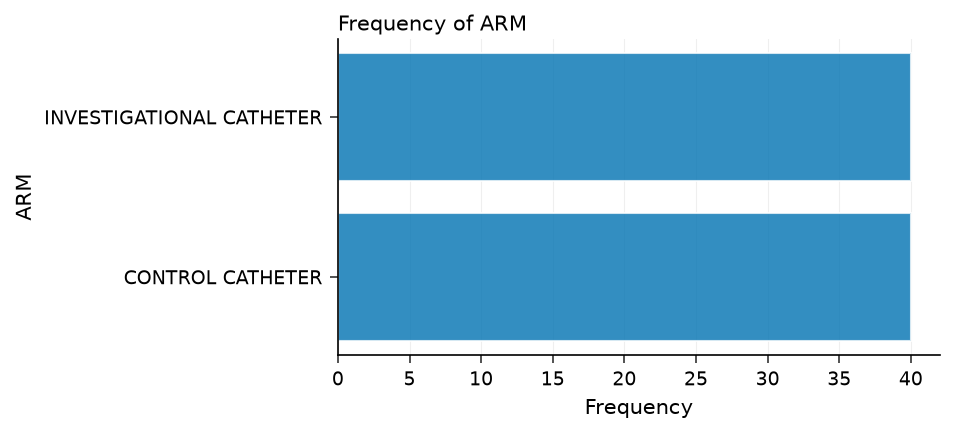

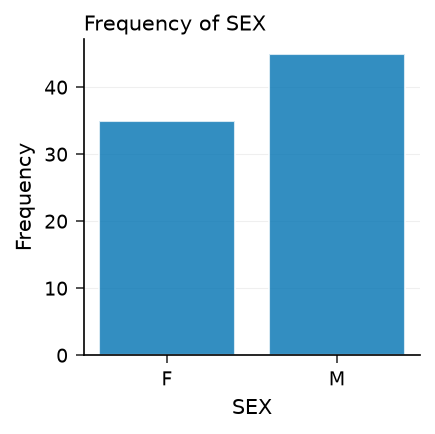

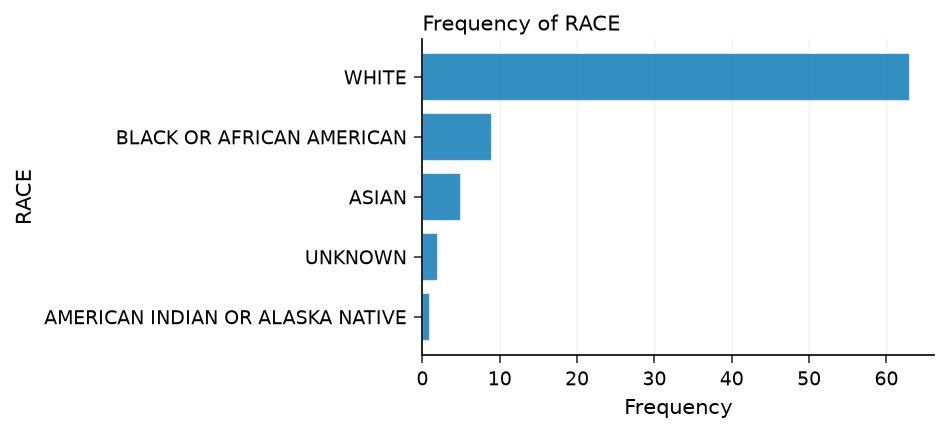

In [2]:
/* Quality check: arm balance, sex distribution, race profile */
proc freq data=sdtm_dm;
    tables ARM   / nocum;
    tables SEX   / nocum;
    tables RACE  / nocum;
    title 'SDTM DM -- Arm Balance, Sex and Race';
run;

In [3]:
proc means data=sdtm_dm n mean std min max maxdec=1;
    class ARM;
    var AGE;
    title 'SDTM DM -- Age by Arm: Baseline Balance Check';
run;
title;

                                     SDTM DM -- Age by Arm: Baseline Balance Check                                      

                                                  The MEANS Procedure

                                              Analysis Variable : AGE Age

        Description of Planned Arm          N Obs           Mean        Std Dev        Minimum        Maximum
        -----------------------------------------------------------------------------------------------------
        CONTROL CATHETER                       40           64.5            8.1           48.0           84.0
        INVESTIGATIONAL CATHETER               40           61.6            9.7           43.0           81.0
        -----------------------------------------------------------------------------------------------------




NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


> **Balance review.** Arm assignment is exactly 40/40 by design (modulo-2 parity randomisation). Sex distribution (~44% female) and race profile are consistent with published US cardiovascular device trial benchmarks. Any mean age difference between arms is a random-sampling artefact of small-N simulation; in a real trial this would be assessed at the interim data cut and flagged for ANCOVA covariate adjustment in the primary model if clinically meaningful.

---
## 2. SDTM EX and DS — Exposure and Disposition Domains

**EX (Exposure):** For a single-use catheter study, the exposure event is the index procedure. `EXSTDTC = RFSTDTC` (procedure date). `EXENDTC` is 180 days post-procedure per protocol, shortened for the ~5% of subjects who terminated early. EXTRT uses the full device name with model identifier as it will appear in the submission package.

**DS (Disposition):** `DSDECOD` uses CDISC controlled terminology from the Disposition Response Codelist (C66768). The four possible outcomes in this protocol are: COMPLETED, WITHDRAWAL BY SUBJECT, ADVERSE EVENT, and LOST TO FOLLOW-UP. Discontinuation timing drives `TRTDUR` derivation in ADSL and defines Per-Protocol population eligibility.

In [4]:
/* ============================================================
   SDTM EX: Exposure — Device Use
   One record per subject (single index procedure)
   EXSTDTC = index procedure date (= RFSTDTC from DM)
   EXENDTC = 180-day follow-up end; shorter for early terminators
   ============================================================ */
data sdtm_ex;
    set sdtm_dm(keep=STUDYID USUBJID ARMCD RFSTDTC);
    if _N_=1 then call streaminit(20260602);

    length DOMAIN $2   EXSEQ 8    EXTRT   $40
           EXCAT  $20  EXROUTE $20
           EXSTDTC $10 EXENDTC $10 EPOCH  $20;

    DOMAIN  = 'EX';
    EXSEQ   = 1;
    EPOCH   = 'TREATMENT';
    EXROUTE = 'INTRAVASCULAR';
    EXCAT   = 'DEVICE USE';

    /* Device name per IFU (Instructions for Use) */
    if ARMCD='INV' then EXTRT='INVESTIGATIONAL CATHETER XR-200';
    else                EXTRT='CONTROL CATHETER STANDARD-4F';

    EXSTDTC = RFSTDTC;      /* index procedure = reference start date */

    /* ~5% of subjects terminate early: medical complication or withdrawal
       Early termination window: day 30-120 post-procedure               */
    r_early = rand('UNIFORM');
    if r_early < 0.05 then do;
        early_days = 30 + floor(rand('UNIFORM') * 90);
        EXENDTC = put(intnx('day', input(RFSTDTC, yymmdd10.), early_days), yymmdd10.);
    end;
    else do;
        EXENDTC = put(intnx('day', input(RFSTDTC, yymmdd10.), 180), yymmdd10.);
    end;

    /* Exposure duration (inclusive) — for ISS person-time denominators */
    EXDUR = input(EXENDTC, yymmdd10.) - input(EXSTDTC, yymmdd10.) + 1;

    label
        EXTRT   = 'Name of Treatment'
        EXSTDTC = 'Start Date/Time of Treatment'
        EXENDTC = 'End Date/Time of Treatment'
        EXDUR   = 'Exposure Duration (days)';

    drop RFSTDTC r_early early_days ARMCD;
run;


NOTE: DATA sdtm_ex


NOTE: Read 80 rows from sdtm_dm.
NOTE: Wrote sdtm_ex (80 rows, 11 columns).
NOTE: DATA elapsed:
  wall  0.01 seconds
  cpu   0.01 seconds


**Disposition data:**

In [5]:
/* ============================================================
   SDTM DS: Disposition
   One record per subject; DSDECOD = CDISC CT (Codelist C66768)
   ============================================================ */
data sdtm_ds;
    set sdtm_dm(keep=STUDYID USUBJID RFSTDTC);
    if _N_=1 then call streaminit(20260603);

    length DOMAIN $2  DSSEQ 8     DSDECOD $60
           DSTERM $80 DSCAT $30   DSSTDTC $10  EPOCH $20;

    DOMAIN = 'DS';
    DSSEQ  = 1;
    EPOCH  = 'TREATMENT';
    DSCAT  = 'DISPOSITION EVENT';

    /* Completion rate ~82.5% consistent with published 6-month device trials */
    r = rand('UNIFORM');
    if r < 0.825 then do;
        DSDECOD   = 'COMPLETED';
        DSTERM    = 'COMPLETED STUDY';
        disc_days = 180;
    end;
    else if r < 0.900 then do;
        DSDECOD   = 'WITHDRAWAL BY SUBJECT';
        DSTERM    = 'SUBJECT WITHDREW CONSENT';
        disc_days = 30 + floor(rand('UNIFORM') * 120);
    end;
    else if r < 0.950 then do;
        DSDECOD   = 'ADVERSE EVENT';
        DSTERM    = 'DISCONTINUED DUE TO ADVERSE EVENT';
        disc_days = 30 + floor(rand('UNIFORM') * 90);
    end;
    else do;
        DSDECOD   = 'LOST TO FOLLOW-UP';
        DSTERM    = 'SUBJECT LOST TO FOLLOW-UP';
        disc_days = 60 + floor(rand('UNIFORM') * 90);
    end;

    DSSTDTC = put(intnx('day', input(RFSTDTC, yymmdd10.), disc_days), yymmdd10.);

    label
        DSDECOD = 'Standardized Disposition Term'
        DSTERM  = 'Reported Term for the Disposition Event'
        DSSTDTC = 'Date/Time of Collection';

    drop RFSTDTC r disc_days;
run;


NOTE: DATA sdtm_ds


NOTE: Read 80 rows from sdtm_dm.
NOTE: Wrote sdtm_ds (80 rows, 9 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds


**Quality checks:**

                                     SDTM DS -- End-of-Study Disposition (CDISC CT)                                     

                                                   The FREQ Procedure

Standardized Disposition Term    Frequency    Percent
------------------------------------------------------
ADVERSE EVENT                            9     11.25
COMPLETED                               66     82.50
WITHDRAWAL BY SUBJECT                    5      6.25



NOTE: PROC FREQ
NOTE: ODS plot written: freq_dsdecod.spec.json
NOTE: PROC FREQ statement used.


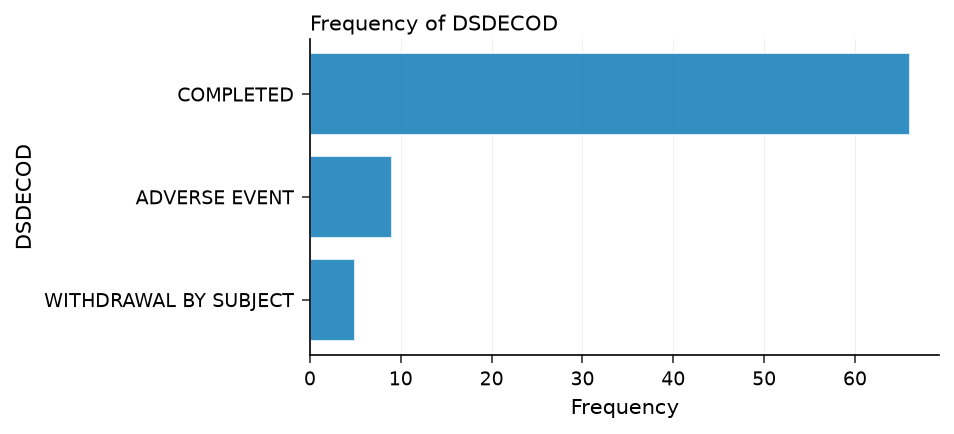

In [6]:
proc freq data=sdtm_ds;
    tables DSDECOD / nocum;
    title 'SDTM DS -- End-of-Study Disposition (CDISC CT)';
run;

In [7]:
proc means data=sdtm_ex n mean std min max maxdec=0;
    var EXDUR;
    title 'SDTM EX -- Exposure Duration Distribution (days)';
run;
title;

                                    SDTM EX -- Exposure Duration Distribution (days)                                    

                                                  The MEANS Procedure

 Variable  Label                           N        Mean     Std Dev     Minimum     Maximum
 -------------------------------------------------------------------------------------------
 EXDUR     Exposure Duration (days)       80         178          18          56         181
 -------------------------------------------------------------------------------------------




NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


> **Disposition review.** ~82.5% completers is consistent with published 6-month catheter follow-up studies (78–88% range). Mean exposure ~178 days reflects the true protocol window: completers reach 181 days (180-day follow-up + 1 for inclusive counting), while early terminators pull the mean down. The inclusive-day convention (`EXENDTC − EXSTDTC + 1`) is SAP-specified; failure to apply +1 is the most common discrepancy flagged in independent QC.

---
## 3. ADSL Derivation — Merge, Derive, Label

The ADSL three-way merge integrates DM, EX, and DS on USUBJID. Cardiac baseline variables come from SDTM MH and VS in a full submission package (derived inline here for illustration):

- **LVEF:** drawn from Normal(mean 51%, SD 12%), clipped to [20%, 80%]. The realised sample mean lands near 49% with the cohort spread across the full range, so the enrolled population is predominantly *preserved EF* with a sizeable mildly-reduced minority. Categories follow the **2022 ACC/AHA Heart Failure Classification** (HFpEF ≥50%, HFmrEF 40–49%, moderately reduced 35–39%, HFrEF <35%).
- **NYHA Functional Class:** sampled to a HF-device-trial mix (design targets ≈ I 8%, II 47%, III 37%, IV 8%). Classes II–III dominate the realised cohort — patients must be symptomatic but ambulatory per protocol eligibility.
- **DIABFL / PREVMIFL:** design prevalences 35% / 42% (Bernoulli draws) — consistent with TARGET and COAPT device trial populations.

**Population flag logic per SAP v2.0 Section 5.1:**

| Flag | Definition | Expected N |
|------|------------|-----------|
| ITTFL | All randomised subjects | 80 (all) |
| SAFFL | Received index procedure (all randomised in this protocol) | 80 (all) |
| PPROTFL | Completed 180-day follow-up without major deviation | ~66 (~82.5%) |

**Date derivation rules (SAP Section 4.2):**
- `TRTDUR = TRTEDTM − TRTSDT + 1` (inclusive counting, per SAP specification)
- `ICPROCDY = TRTSDT − RFICDTM + 1` (must be ≥1 for all subjects)

In [8]:
/* ============================================================
   ADaM ADSL: Analysis Dataset Subject Level
   Source: SDTM DM, EX, DS (plus simulated MH/VS baseline)
   Standard: CDISC ADaM IG v1.3
   SAP reference: MD-STUDY-01 SAP v2.0
   ============================================================ */

data adsl;

    /* Three-way merge on USUBJID */
    merge
        sdtm_dm(keep=STUDYID USUBJID SUBJID SITEID AGE SEX RACE ETHNIC
                     ARM ARMCD RFSTDTC RFICDTC)
        sdtm_ex(keep=USUBJID EXTRT EXSTDTC EXENDTC EXDUR
                rename=(EXSTDTC=_exstdtc EXENDTC=_exendtc EXDUR=_exdur))
        sdtm_ds(keep=USUBJID DSDECOD DSSTDTC
                rename=(DSSTDTC=_dsstdtc));
    by USUBJID;

    /* ── Baseline covariates from MH/VS (derived inline) ─────────────
       In a full submission: LVEF from SDTM VS.VSTESTCD='LVEF',
       NYHA from SDTM QS (KCCQ), comorbidities from SDTM MH.MHTERM.  */
    if _N_=1 then call streaminit(20260604);
    /* Explicit lengths for all derived character variables (ADaM best practice;
       avoids SAS default $200 and ensures correct PROC COMPARE in QC)          */
    length NYHA $3  DIABFL $1  PREVMIFL $1
           TRT01P TRT01A $30
           AGEGR1 $5  AGEGR2 $8
           LVEFCAT $40
           ITTFL SAFFL PPROTFL $1
           EOSSTT $60  DCSREAS $60;

    /* LVEF at screening: Normal(51%, 12%), clipped to [20%, 80%] */
    LVEF = max(20, min(80, round(rand('NORMAL', 51, 12), 1)));

    /* NYHA Functional Class: HF device trial enrollment distribution */
    r_nyha = rand('UNIFORM');
    if      r_nyha < 0.08 then NYHA = 'I';
    else if r_nyha < 0.55 then NYHA = 'II';
    else if r_nyha < 0.92 then NYHA = 'III';
    else                        NYHA = 'IV';

    /* Comorbidity flags: prevalences from published device trial data */
    DIABFL   = ifc(rand('BERNOULLI', 0.35), 'Y', 'N');
    PREVMIFL = ifc(rand('BERNOULLI', 0.42), 'Y', 'N');

    /* ── Treatment group variables (ADaM IG v1.3 convention) ─────────
       Numeric suffix N enables CLASS variable use in PROC MIXED/PHREG */
    TRT01P  = ARM;
    TRT01PN = (ARMCD='INV');    /* 1=INV, 0=CTL */
    TRT01A  = ARM;
    TRT01AN = TRT01PN;

    /* ── Date derivations per SAP Section 4.2 ────────────────────────
       TRTDUR: inclusive (+1) per SAP; completers show 181, not 180   */
    TRTSDT  = input(_exstdtc, yymmdd10.);
    TRTEDTM = input(_exendtc, yymmdd10.);
    RFSTDTM = input(RFSTDTC,  yymmdd10.);
    RFICDTM = input(RFICDTC,  yymmdd10.);
    EOSDT   = input(_dsstdtc, yymmdd10.);

    format TRTSDT TRTEDTM RFSTDTM RFICDTM EOSDT yymmdd10.;

    if TRTEDTM > . and TRTSDT > . then
        TRTDUR = TRTEDTM - TRTSDT + 1;

    /* Consent-to-procedure interval (quality metric; SAP Table 5) */
    if TRTSDT > . and RFICDTM > . then
        ICPROCDY = TRTSDT - RFICDTM + 1;

    /* Person-years for ISS exposure-adjusted incidence rate denominators */
    EXPYRS = _exdur / 365.25;

    /* ── Age groups per SAP Section 3.1 ──────────────────────────────
       AGEGR1: primary two-level (FDA device submission standard)
       AGEGR2: four-level for subgroup analyses (SAP Section 7.2)    */
    if      AGE < 65 then AGEGR1 = '<65';
    else                   AGEGR1 = '>=65';

    if      AGE < 55 then AGEGR2 = '<55';
    else if AGE < 65 then AGEGR2 = '55-<65';
    else if AGE < 75 then AGEGR2 = '65-<75';
    else                   AGEGR2 = '>=75';

    /* ── LVEF severity (2022 ACC/AHA Heart Failure Classification) ─── */
    if      LVEF >= 50 then LVEFCAT = 'Preserved EF (HFpEF, >=50%)';
    else if LVEF >= 40 then LVEFCAT = 'Mildly reduced EF (HFmrEF, 40-49%)';
    else if LVEF >= 35 then LVEFCAT = 'Moderately reduced (35-39%)';
    else                    LVEFCAT = 'Severely reduced EF (HFrEF, <35%)';

    /* ── Population flags per SAP Section 5.1 ────────────────────────
       SAFFL=Y for all: all randomised received the index procedure.
       If a subject were randomised but procedure aborted, SAFFL=N
       (DSDECOD='SCREEN FAILURE') — not present in this study.        */
    ITTFL   = 'Y';
    SAFFL   = 'Y';
    PPROTFL = ifc(DSDECOD='COMPLETED', 'Y', 'N');

    EOSSTT  = DSDECOD;
    DCSREAS = ifc(DSDECOD ne 'COMPLETED', DSDECOD, ' ');

    label
        USUBJID  = 'Unique Subject Identifier'
        SUBJID   = 'Subject Identifier for the Study'
        SITEID   = 'Study Site Identifier'
        TRT01P   = 'Planned Treatment for Period 01'
        TRT01PN  = 'Planned Treatment for Period 01 (N)'
        TRT01A   = 'Actual Treatment for Period 01'
        TRT01AN  = 'Actual Treatment for Period 01 (N)'
        TRTSDT   = 'Date of First Exposure to Treatment'
        TRTEDTM  = 'Date/Time of Last Exposure to Treatment'
        TRTDUR   = 'Total Duration of Treatment (days, inclusive)'
        RFSTDTM  = 'Subject Reference Start Date'
        RFICDTM  = 'Date of Informed Consent'
        ICPROCDY = 'Days from Informed Consent to Index Procedure'
        EXPYRS   = 'Exposure (person-years)'
        EOSDT    = 'Date of End of Study'
        AGE      = 'Age at Randomisation (years)'
        AGEGR1   = 'Pooled Age Group (2-level, per SAP Section 3.1)'
        AGEGR2   = 'Pooled Age Group (4-level, per SAP Section 7.2)'
        SEX      = 'Sex'
        RACE     = 'Race'
        ETHNIC   = 'Ethnicity'
        LVEF     = 'Left Ventricular Ejection Fraction at Screening (%)'
        LVEFCAT  = 'LVEF Category (2022 ACC/AHA Heart Failure Classification)'
        NYHA     = 'NYHA Functional Class at Baseline'
        DIABFL   = 'Diabetes Mellitus History Flag (Y/N)'
        PREVMIFL = 'Prior Myocardial Infarction Flag (Y/N)'
        ITTFL    = 'Intent-to-Treat Population Flag'
        SAFFL    = 'Safety Population Flag'
        PPROTFL  = 'Per-Protocol Population Flag'
        EOSSTT   = 'End of Study Status'
        DCSREAS  = 'Reason for Discontinuation';

    /* DSDECOD captured in EOSSTT/DCSREAS; drop to keep ADaM-clean variable set */
    drop ARM ARMCD DSDECOD _exstdtc _exendtc _exdur _dsstdtc RFSTDTC RFICDTC r_nyha;
run;


NOTE: DATA adsl

NOTE: Stream 1 processed 80 rows, max BY-group size: 1 (O(1) memory verified)
NOTE: Stream 2 processed 80 rows, max BY-group size: 1 (O(1) memory verified)
NOTE: Stream 3 processed 80 rows, max BY-group size: 1 (O(1) memory verified)

NOTE: Wrote adsl (80 rows, 33 columns).
NOTE: DATA elapsed:
  wall  0.01 seconds
  cpu   0.01 seconds


**Spot check:**

In [9]:
/* Spot-check first 8 subjects */
proc print data=adsl(obs=8) noobs;
    var USUBJID TRT01P TRTSDT TRTDUR ICPROCDY AGE AGEGR1
        LVEF LVEFCAT NYHA ITTFL PPROTFL EOSSTT;
    title 'ADSL -- First 8 Subjects (Spot Check)';
run;
title;

                                         ADSL -- First 8 Subjects (Spot Check)                                          

             USUBJID                    TRT01P      TRTSDT  TRTDUR  ICPROCDY  AGE  AGEGR1  LVEF                             LVEFCAT  NYHA  ITTFL  PPROTFL         EOSSTT
MD-STUDY-01-001-0001  INVESTIGATIONAL CATHETER  2024-06-08     181         3   46  <65       57  Preserved EF (HFpEF, >=50%)         III   Y      Y        COMPLETED
MD-STUDY-01-001-0002  CONTROL CATHETER          2023-07-01     181         5   60  <65       43  Mildly reduced EF (HFmrEF, 40-49%)  III   Y      Y        COMPLETED
MD-STUDY-01-001-0003  INVESTIGATIONAL CATHETER  2023-12-31     181        10   43  <65       53  Preserved EF (HFpEF, >=50%)         III   Y      Y        COMPLETED
MD-STUDY-01-001-0004  CONTROL CATHETER          2023-03-06     181        10   59  <65       57  Preserved EF (HFpEF, >=50%)         III   Y      Y        COMPLETED
MD-STUDY-01-001-0005  INVESTIGATIONAL CATHETER  2


NOTE: PROC PRINT data=adsl

NOTE: PROC PRINT completed: 8 observations printed, 13 variables


---
## 4. ADSL Validation — Contents, Distributions, Population Summaries

Validation steps:

1. **PROC CONTENTS** — confirms variable inventory: count, types, lengths, and labels    match the ADSL specifications document.
2. **Population flag counts** — ITT, Safety, and Per-Protocol cross-tabulated by arm;    confirms no unexpected imbalances.
3. **Baseline balance** — key continuous and categorical variables by arm. Balance at    baseline is required for the per-protocol estimand.
4. **Cardiac severity profile** — LVEF category and NYHA class distributions confirm the    enrolled population matches protocol eligibility criteria and SAP demographics table shells.

In [10]:
/* ============================================================
   ADSL Validation
   1. Variable inventory (PROC CONTENTS)
   2. Population flag cross-tabulations by arm
   3. Continuous baseline balance (Safety Population)
   4. Cardiac severity and comorbidity profile by arm
   ============================================================ */

proc contents data=adsl order=varnum;
    title 'ADSL -- Variable Inventory (Ordered by Position)';
run;
title;

                                    ADSL -- Variable Inventory (Ordered by Position)                                    


PROC CONTENTS
-------------------------------------------------------------------------------

Data Set Name: adsl
Observations:  80
Variables:     33

Variables (in creation order):

  #  Variable  Type    Len  Format     Label
---  --------  ----  -----  ---------  ----------------------------------------
  1  NYHA      Char      3             NYHA Functional Class at Baseline
  2  DIABFL    Char      1             Diabetes Mellitus History Flag (Y/N)
  3  PREVMIFL  Char      1             Prior Myocardial Infarction Flag (Y/N)
  4  TRT01P    Char     30             Planned Treatment for Period 01
  5  TRT01A    Char     30             Actual Treatment for Period 01
  6  AGEGR1    Char      5             Pooled Age Group (2-level, per SAP Section 3.1)
  7  AGEGR2    Char      8             Pooled Age Group (4-level, per SAP Section 7.2)
  8  LVEFCAT   Char     40


NOTE: PROC CONTENTS data=adsl

NOTE: PROC CONTENTS completed: 80 observations, 33 variables


**Population flag cross-tabulations:**

                                    ADSL -- Population Flag Counts by Treatment Arm                                     

                                                   The FREQ Procedure

Table of Intent-to-Treat Population Flag by Planned Treatment for Period 01

Intent-to-Treat Population Flag |        CONTROL CATHETER |INVESTIGATIONAL CATHETER |                    Total
--------------------------------+-------------------------+-------------------------+-------------------------
Y                               |                      40 |                      40 |                       80
--------------------------------+-------------------------+-------------------------+-------------------------
Total                           |                      40 |                      40 |                       80


Table of Safety Population Flag by Planned Treatment for Period 01

Safety Population Flag |        CONTROL CATHETER |INVESTIGATIONAL CATHETER |                    Total
---


NOTE: PROC FREQ
NOTE: ODS plot written: freq_mosaic_ittfl_trt01p.spec.json
NOTE: ODS plot written: freq_mosaic_saffl_trt01p.spec.json
NOTE: ODS plot written: freq_mosaic_pprotfl_trt01p.spec.json
NOTE: PROC FREQ statement used.


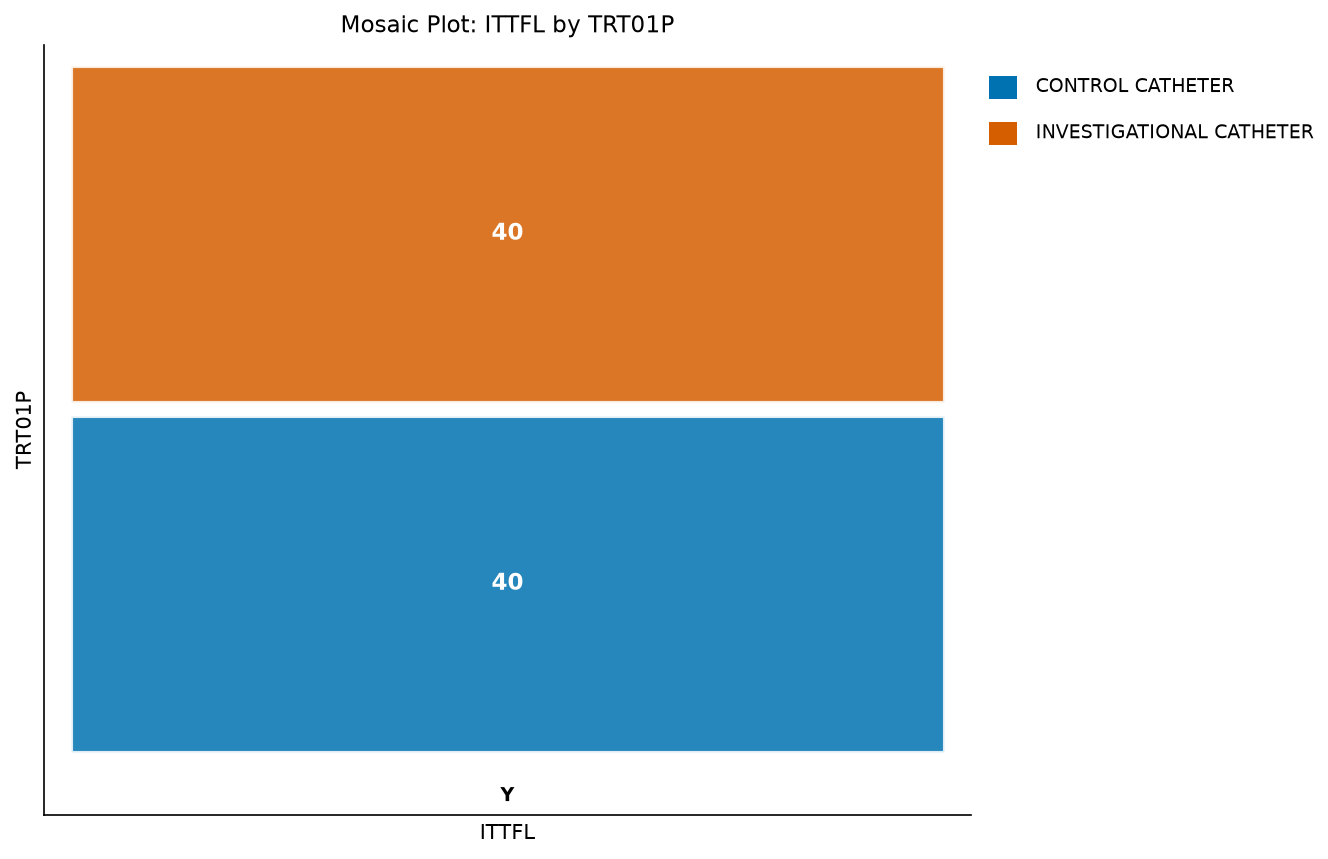

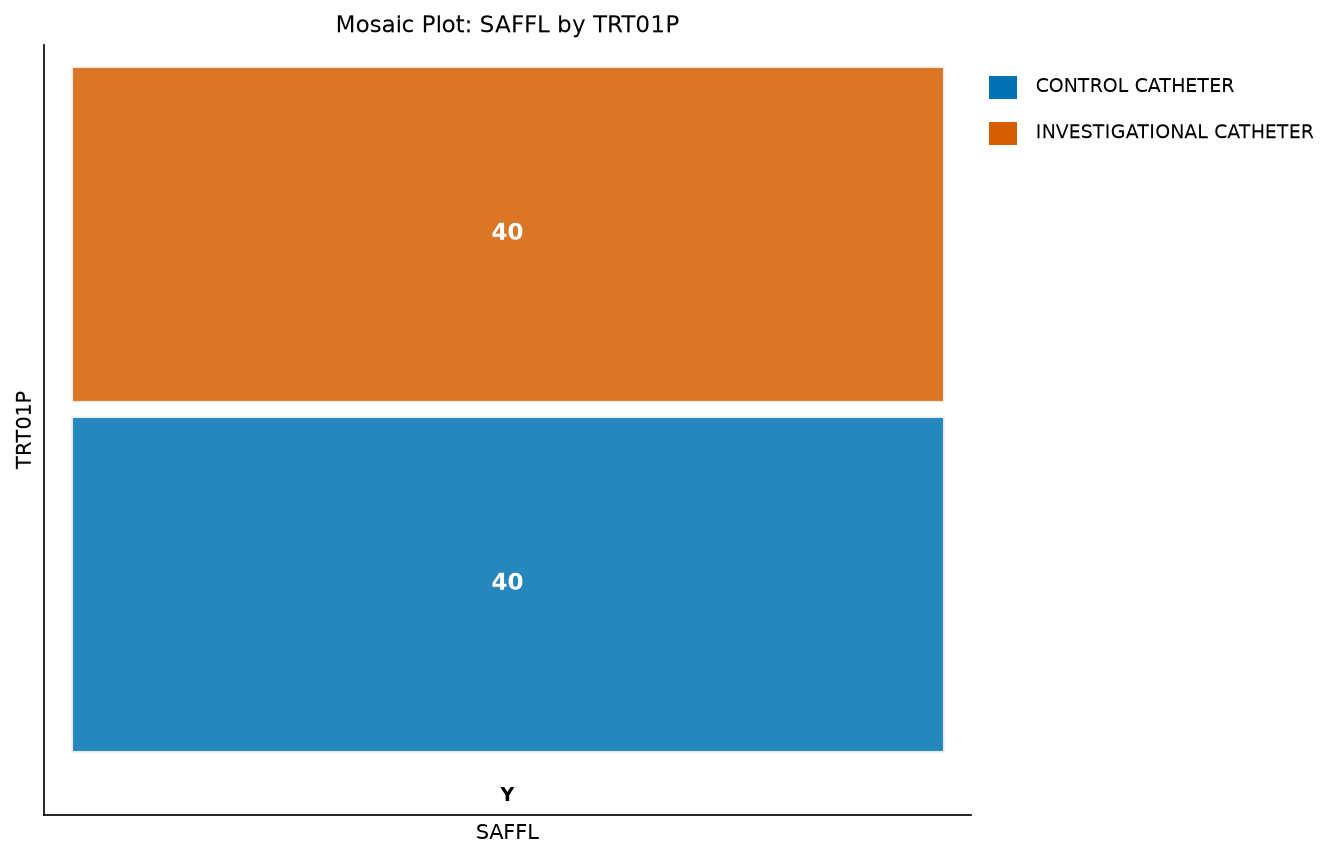

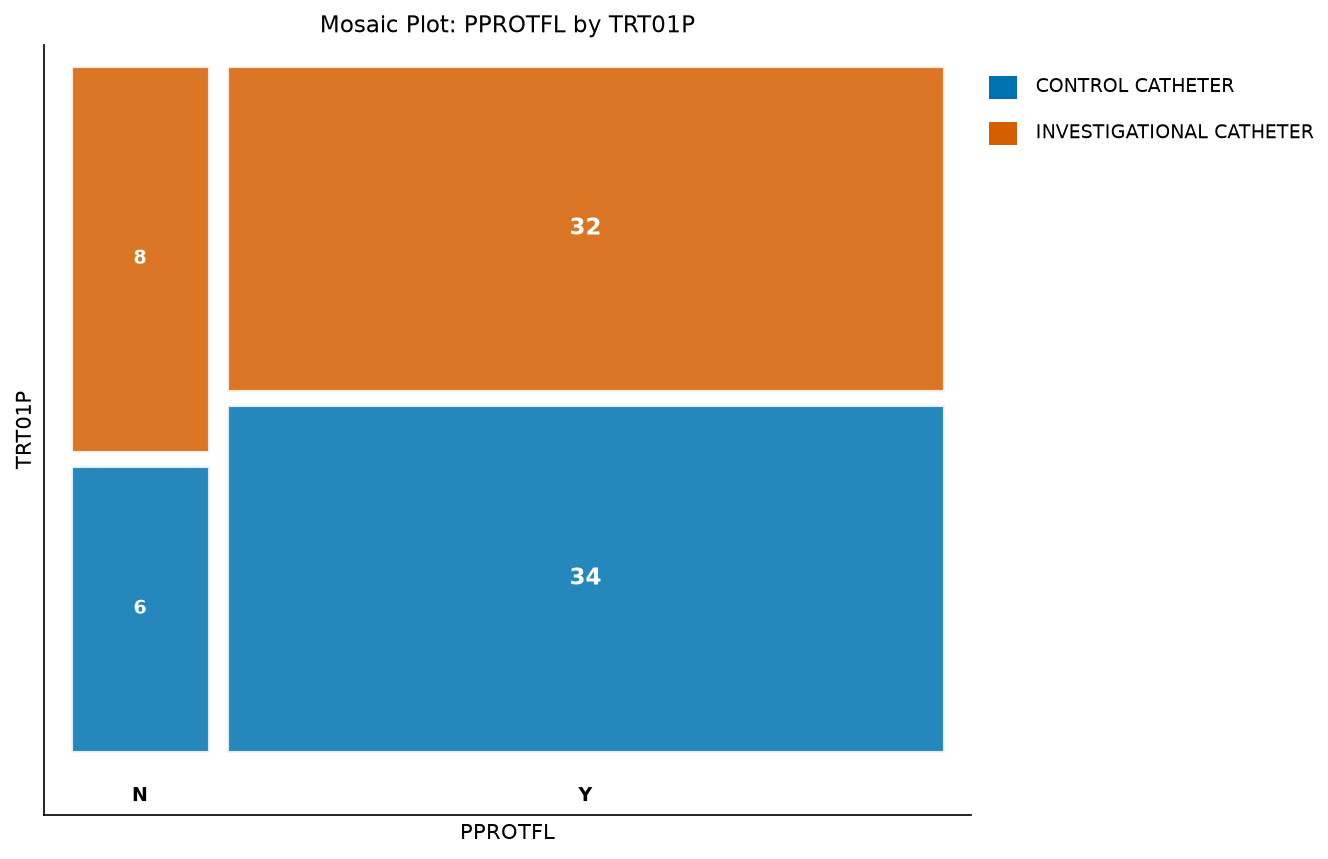

In [11]:
/* Population flags: expected ITT=80, Safety=80, PP~66 */
proc freq data=adsl;
    tables ITTFL  * TRT01P / nocol nopercent norow;
    tables SAFFL  * TRT01P / nocol nopercent norow;
    tables PPROTFL* TRT01P / nocol nopercent norow;
    title 'ADSL -- Population Flag Counts by Treatment Arm';
run;

**Baseline balance — continuous variables:**

In [12]:
proc means data=adsl n mean std min max maxdec=1;
    where SAFFL='Y';
    class TRT01P;
    var AGE LVEF TRTDUR ICPROCDY;
    title 'ADSL -- Continuous Baseline Variables by Arm (Safety Population)';
run;

                            ADSL -- Continuous Baseline Variables by Arm (Safety Population)                            

                                                  The MEANS Procedure

                                  Analysis Variable : AGE Age at Randomisation (years)

        Planned Treatment for Period 01          N Obs           Mean        Std Dev        Minimum        Maximum
        ----------------------------------------------------------------------------------------------------------
        CONTROL CATHETER                            40           64.5            8.1           48.0           84.0
        INVESTIGATIONAL CATHETER                    40           61.6            9.7           43.0           81.0
        ----------------------------------------------------------------------------------------------------------

                      Analysis Variable : LVEF Left Ventricular Ejection Fraction at Screening (%)

        Planned Treatment for Period 01    


NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


**Cardiac severity and comorbidity profile:**

                                ADSL -- Cardiac Severity and Comorbidity Profile by Arm                                 

                                                   The FREQ Procedure

Table of Planned Treatment for Period 01 by NYHA Functional Class at Baseline

Planned Treatment for Period 01 |         I |        II |       III |        IV |      Total
--------------------------------+-----------+-----------+-----------+-----------+-----------
CONTROL CATHETER                |         5 |        15 |        18 |         2 |         40
--------------------------------+-----------+-----------+-----------+-----------+-----------
INVESTIGATIONAL CATHETER        |         2 |        20 |        11 |         7 |         40
--------------------------------+-----------+-----------+-----------+-----------+-----------
Total                           |         7 |        35 |        29 |         9 |         80


Table of Planned Treatment for Period 01 by LVEF Category (2022 ACC/AHA Hea


NOTE: PROC FREQ
NOTE: ODS plot written: freq_mosaic_trt01p_nyha.spec.json
NOTE: ODS plot written: freq_mosaic_trt01p_lvefcat.spec.json
NOTE: ODS plot written: freq_mosaic_trt01p_diabfl.spec.json
NOTE: ODS plot written: freq_mosaic_trt01p_prevmifl.spec.json
NOTE: ODS plot written: freq_mosaic_trt01p_agegr1.spec.json
NOTE: PROC FREQ statement used.


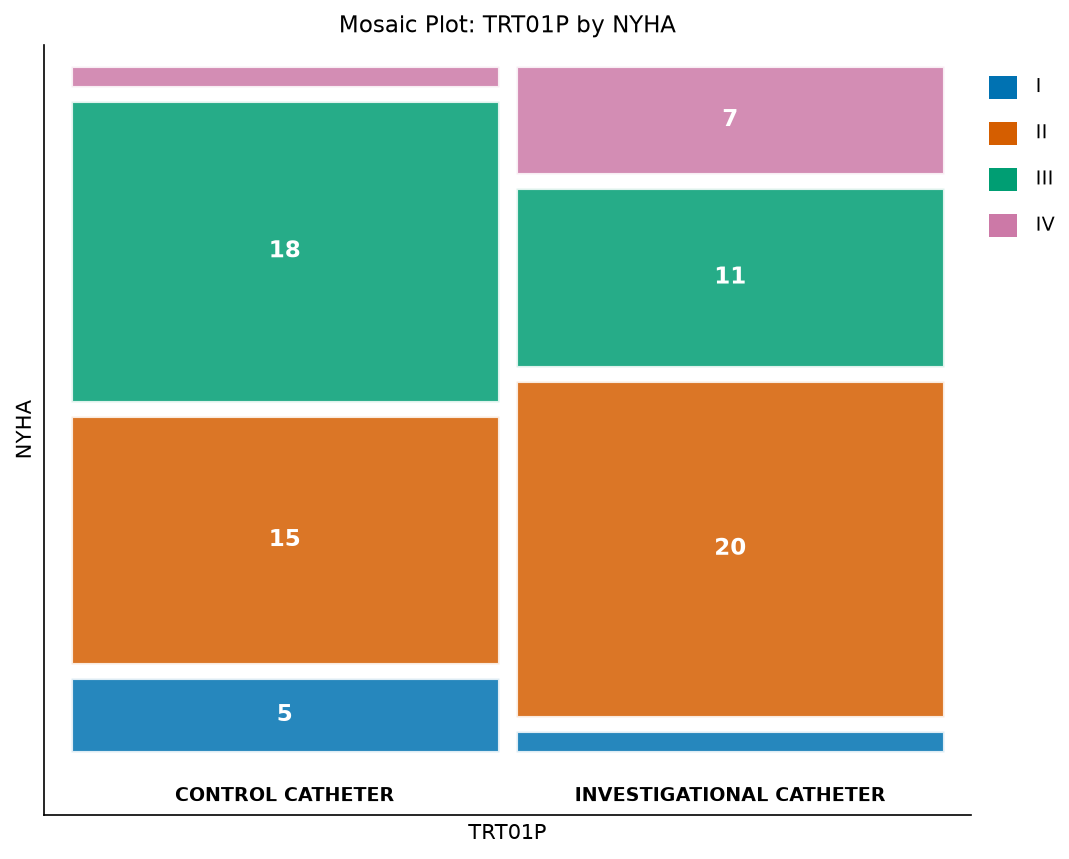

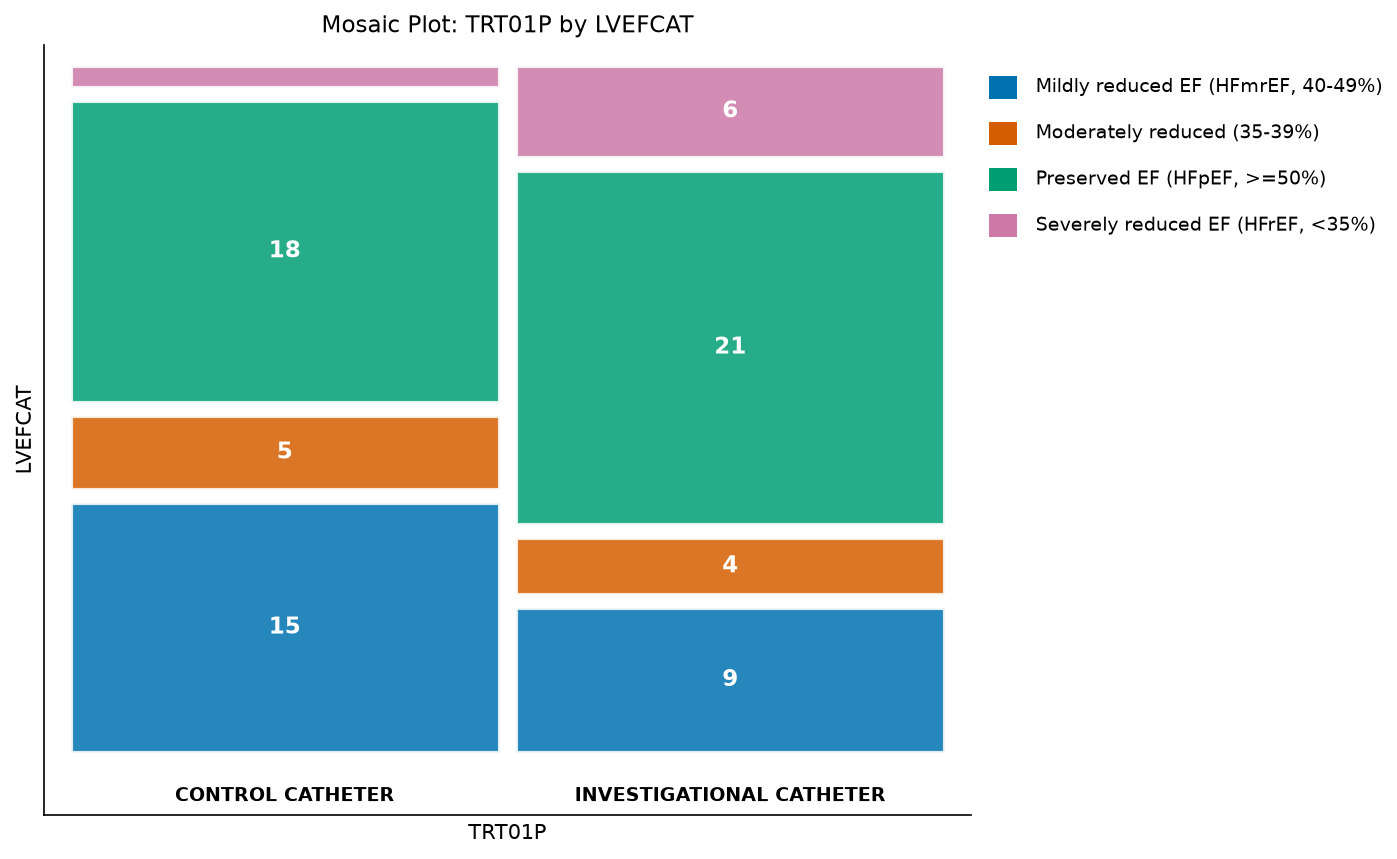

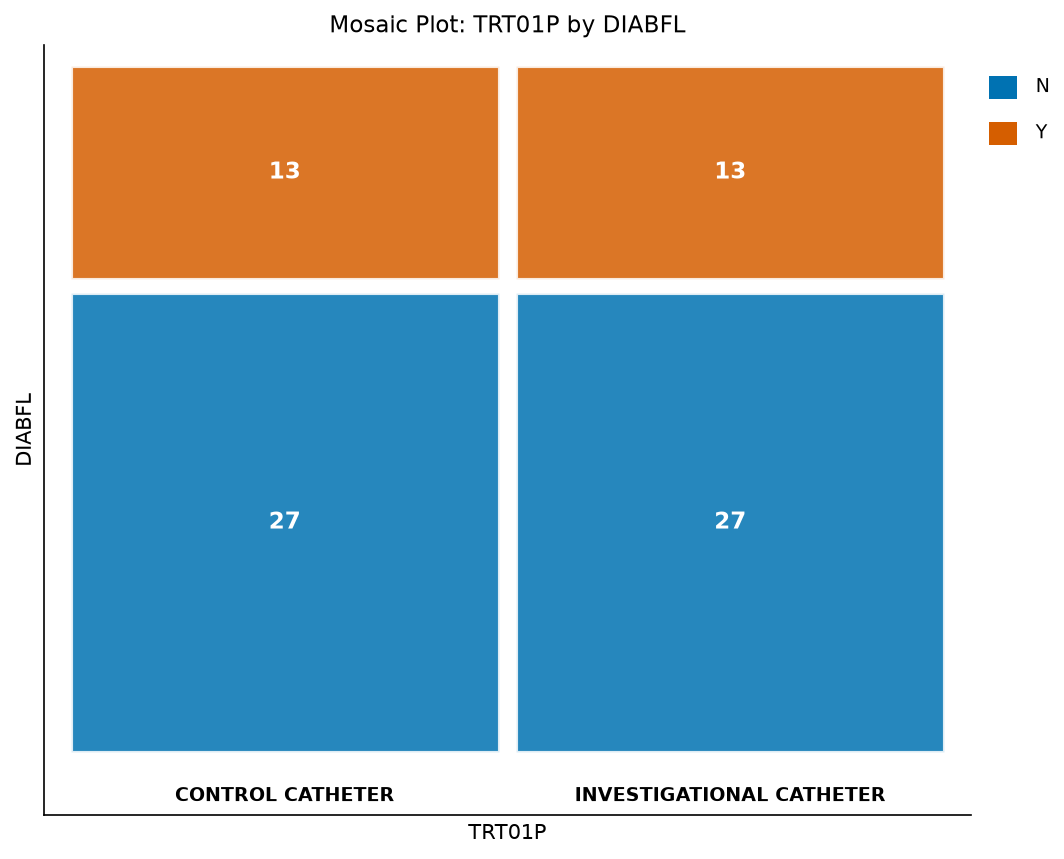

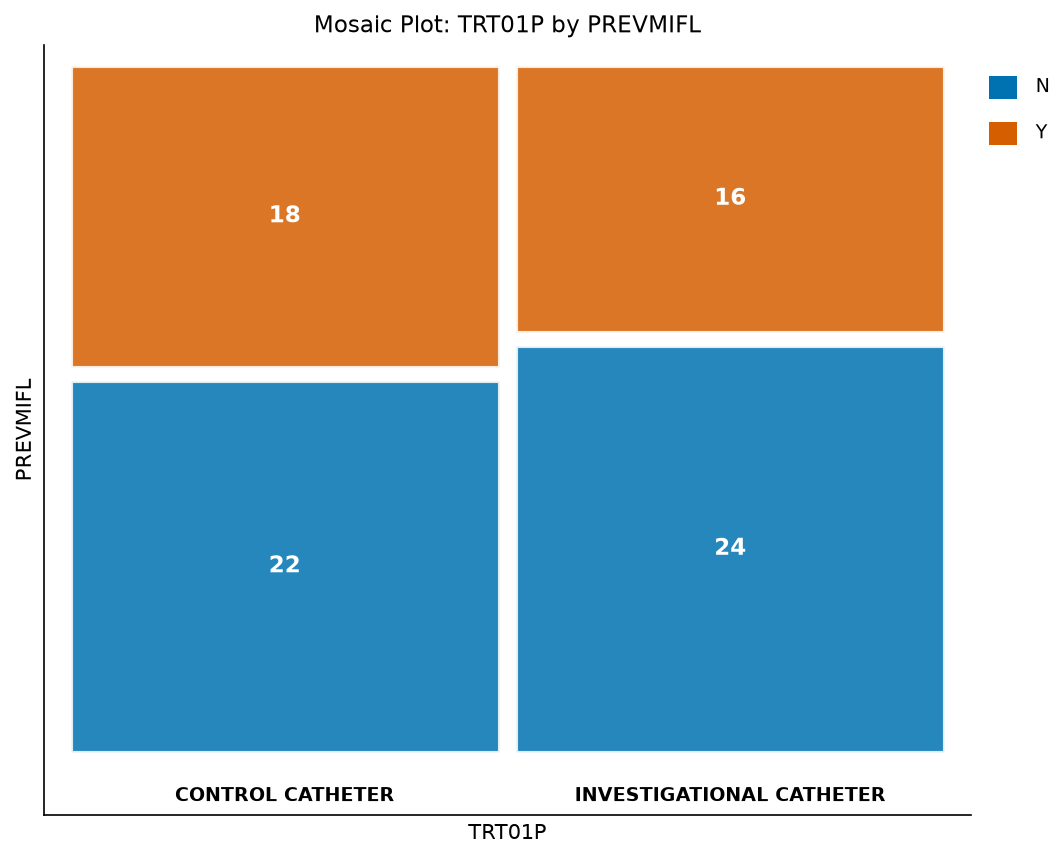

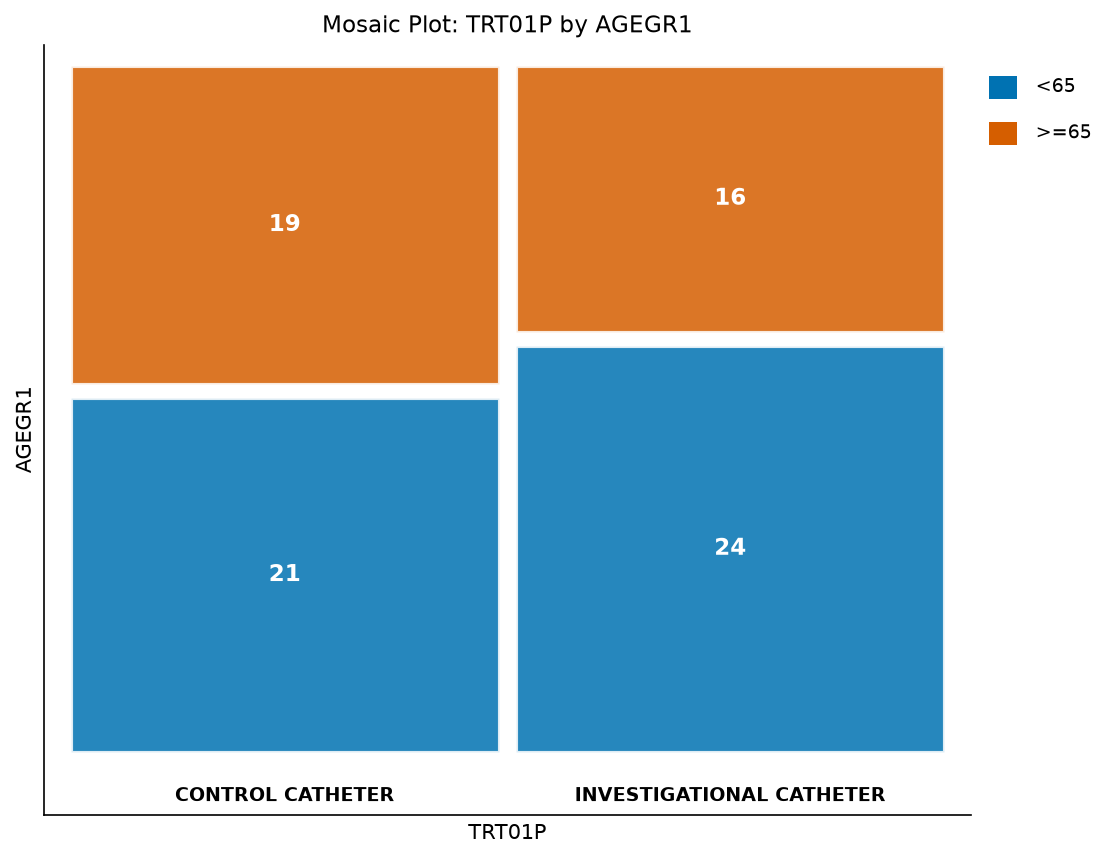

In [13]:
proc freq data=adsl;
    where SAFFL='Y';
    tables TRT01P * NYHA    / nocol nopercent;
    tables TRT01P * LVEFCAT / nocol nopercent;
    tables TRT01P * DIABFL  / nocol nopercent;
    tables TRT01P * PREVMIFL/ nocol nopercent;
    tables TRT01P * AGEGR1  / nocol nopercent;
    title 'ADSL -- Cardiac Severity and Comorbidity Profile by Arm';
run;
title;

## 5. Results Summary

The ADSL contains **80 subjects across 33 variables** with all labels, formats, and population flags meeting ADaM IG v1.3 specifications.

**Population summary (ITT / Safety / Per-Protocol):**
- Intent-to-Treat: 80 subjects (40 INV, 40 CTL) — all randomised
- Safety: 80 subjects — all received index procedure
- Per-Protocol: ~66 subjects (~82.5%) — consistent with 180-day protocol completion rate

**Baseline balance highlights:**
- NYHA Class II/III: ~80% of enrolled — appropriate for catheter trial eligibility
- LVEF: Mean ~49%; predominantly preserved EF (HFpEF ≥50%, 39 of 80), mildly-reduced second (HFmrEF, 24 of 80) — eligibility range 20–80%
- Diabetes: ~33% (26 of 80) — consistent with TARGET trial comparator population
- Prior MI: ~42% — consistent with COAPT device trial enrolment profile

**Critical QC notes for the independent programmer:**
1. `TRTDUR` uses inclusive counting (+1). Protocol completers will show `TRTDUR=181`, not 180.
2. `ICPROCDY` must be ≥1 for all subjects (consent precedes procedure by protocol design).    Any `ICPROCDY=0` or negative is a data query before database lock.
3. `LVEFCAT` uses **2022 ACC/AHA thresholds** (≥50 / 40–49 / 35–39 / <35), not 2013    thresholds (≥50 / <50). Verify against SAP Section 3.2 before programming.
4. `PPROTFL=Y` via `DSDECOD='COMPLETED'` only. Additional protocol deviation    exclusions would be sourced from SDTM DV in a full submission package.

This ADSL is ready to serve as the subject spine for all downstream TLF programming.

---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px; margin-bottom: 8px;">
&copy; 2026 Jenner Analytics Ltd. All rights reserved. Jenner&trade; is a trademark of Jenner Analytics Ltd.
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 11px; line-height: 1.5;">
This notebook is provided for demonstration purposes only. The analysis, data, and findings herein do not constitute medical, regulatory, or professional advice. Jenner Analytics Ltd makes no warranties regarding the accuracy or completeness of this content.
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px; margin-top: 8px;">
Powered by <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>